# Figure Generation — Material Classification Method Report

Produces all PNGs referenced by `Research/Material_Classification_Methods_2026-05-13.docx`. Saves to `Research/figures/`.

In [1]:
import os, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score
from tensorflow.keras.models import load_model

BASE = os.path.abspath(os.path.join(os.getcwd(), '..')) if not os.path.exists('CLAUDE.md') else os.path.abspath('.')
DATA_DIR  = os.path.join(BASE, 'data_logs', 'datasets')
MODEL_DIR = os.path.join(BASE, 'Model')
FIG_DIR   = os.path.join(BASE, 'Research', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)
print('Figures dir:', FIG_DIR)

plt.rcParams.update({
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'legend.fontsize': 10, 'figure.dpi': 110, 'savefig.dpi': 160,
    'savefig.bbox': 'tight',
})

Figures dir: C:\Users\charm\OneDrive\documents\Arduino\PIDpwm\Research\figures


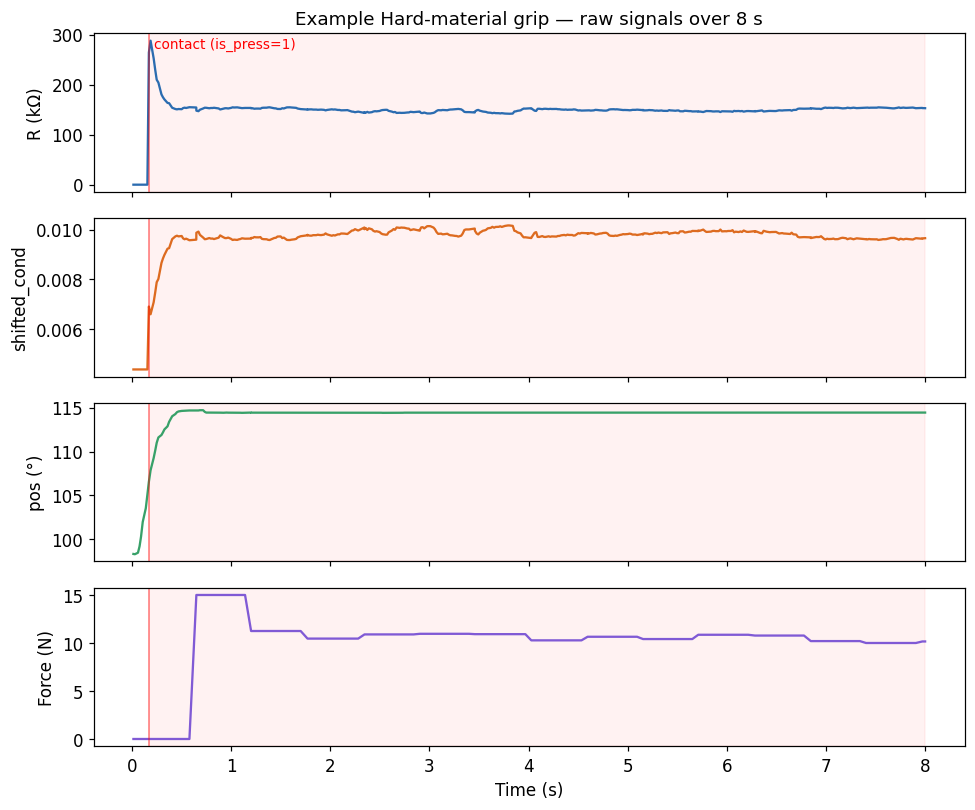

Saved C:\Users\charm\OneDrive\documents\Arduino\PIDpwm\Research\figures\fig1_example_signal.png


In [2]:
# Fig 1 — Example signal trace from one Hard trial
df = pd.read_csv(os.path.join(DATA_DIR, 'Hard (1).csv'))
trial = df[df['loop_index'] == 1].copy()
trial['t_s'] = trial['t_ms'] / 1000.0
contact_t = trial[trial['is_press'] == 1]['t_s'].iloc[0] if (trial['is_press'] == 1).any() else None

fig, axes = plt.subplots(4, 1, figsize=(9, 7.5), sharex=True)
axes[0].plot(trial['t_s'], trial['resistance']/1000.0, color='#2b6cb0'); axes[0].set_ylabel('R (kΩ)')
axes[0].set_title('Example Hard-material grip — raw signals over 8 s')
axes[1].plot(trial['t_s'], trial['shifted_cond'], color='#dd6b20'); axes[1].set_ylabel('shifted_cond')
axes[2].plot(trial['t_s'], trial['pos_deg'], color='#38a169'); axes[2].set_ylabel('pos (°)')
axes[3].plot(trial['t_s'], trial['pred_force_n'], color='#805ad5'); axes[3].set_ylabel('Force (N)')
axes[3].set_xlabel('Time (s)')
for ax in axes:
    if contact_t is not None:
        ax.axvline(contact_t, color='red', alpha=0.5, lw=1)
        ax.axvspan(contact_t, trial['t_s'].max(), color='red', alpha=0.05)
axes[0].text(contact_t + 0.05, axes[0].get_ylim()[1]*0.9, 'contact (is_press=1)', color='red', fontsize=9)
out = os.path.join(FIG_DIR, 'fig1_example_signal.png')
plt.tight_layout(); plt.savefig(out); plt.show()
print('Saved', out)

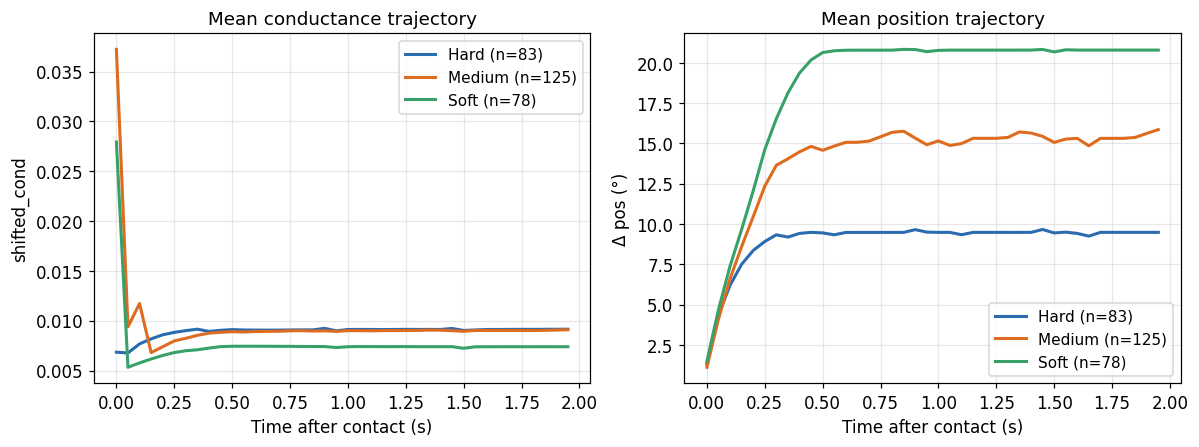

Saved C:\Users\charm\OneDrive\documents\Arduino\PIDpwm\Research\figures\fig2_class_mean_trajectories.png


In [3]:
# Fig 2 — Class-mean shifted_cond and pos trajectories (post-contact, first 2 s)
from collections import defaultdict

WIN_S = 2.0
STEP_S = 0.05  # 20 Hz
by_class = defaultdict(lambda: defaultdict(list))
label_map = {'hard': 'Hard', 'medium': 'Medium', 'soft': 'Soft'}
for fn in sorted(os.listdir(DATA_DIR)):
    if not fn.lower().endswith('.csv'): continue
    fp = os.path.join(DATA_DIR, fn)
    head = pd.read_csv(fp, nrows=3)
    mats = head['material'].dropna().astype(str).str.lower().unique().tolist() if 'material' in head.columns else []
    lbl = label_map.get(mats[0]) if mats else None
    if lbl is None: continue
    df = pd.read_csv(fp)
    for li, g in df.groupby('loop_index'):
        post = g[g['is_press']==1].sort_values('t_ms').reset_index(drop=True)
        if len(post) < 10: continue
        t0 = float(post['t_ms'].iloc[0])
        pos0 = float(post['pos_deg'].iloc[0])
        rel = (post['t_ms'].astype(float) - t0).values / 1000.0
        # bin to 50 ms grid
        max_bin = min(int(WIN_S / STEP_S), int(rel[-1] / STEP_S) + 1)
        cond = np.full(max_bin, np.nan); dp = np.full(max_bin, np.nan)
        bin_id = (rel // STEP_S).astype(int)
        for b in range(max_bin):
            mask = bin_id == b
            if mask.any():
                cond[b] = post.loc[mask, 'shifted_cond'].mean()
                dp[b]   = post.loc[mask, 'pos_deg'].mean() - pos0
        by_class[lbl]['cond'].append(cond)
        by_class[lbl]['dp'].append(dp)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
colors = {'Hard': '#2b6cb0', 'Medium': '#dd6b20', 'Soft': '#38a169'}
for lbl, d in by_class.items():
    L = int(WIN_S / STEP_S)
    cond_pad = [np.concatenate([c, np.full(L - len(c), np.nan)]) for c in d['cond']]
    dp_pad   = [np.concatenate([c, np.full(L - len(c), np.nan)]) for c in d['dp']]
    cond_mean = np.nanmean(np.stack(cond_pad), axis=0)
    dp_mean   = np.nanmean(np.stack(dp_pad),   axis=0)
    t = np.arange(L) * STEP_S
    axes[0].plot(t, cond_mean, label=f'{lbl} (n={len(d["cond"])})', color=colors[lbl], lw=2)
    axes[1].plot(t, dp_mean,   label=f'{lbl} (n={len(d["dp"])})',   color=colors[lbl], lw=2)
axes[0].set_xlabel('Time after contact (s)'); axes[0].set_ylabel('shifted_cond'); axes[0].set_title('Mean conductance trajectory')
axes[1].set_xlabel('Time after contact (s)'); axes[1].set_ylabel('Δ pos (°)'); axes[1].set_title('Mean position trajectory')
for ax in axes:
    ax.grid(alpha=0.3); ax.legend()
out = os.path.join(FIG_DIR, 'fig2_class_mean_trajectories.png')
plt.tight_layout(); plt.savefig(out); plt.show()
print('Saved', out)

In [4]:
# Compute RF + CNN predictions on the back-test set (same as backtest notebook).
import json
RF_FEATURES = ['delta_pos_max','res_drop_pct','f_peak','rise_ms','stiffness_proxy']
CNN_FEATURES = ['shifted_cond','delta_pos','d_cond_dt','d_dpos_dt','res_norm']
WINDOW_LEN, BIN_MS = 40, 50

def extract_rf(g):
    if len(g) < 30: return None, None
    pre = g[g['is_press']==0]; post = g[g['is_press']==1]
    if len(pre)<5 or len(post)<5: return None, None
    bres = float(pre['resistance'].median())/1000.0
    mres = float(post['resistance'].min())/1000.0
    rdp  = (bres-mres)/max(bres,1e-6)
    pac  = float(post['pos_deg'].iloc[0])
    dpm  = abs(float(post['pos_deg'].min())-pac)
    fp   = float(post['pred_force_n'].max())
    if fp<1.5: return None, None
    if bres<1000 and fp<5: return None, None
    tc = float(post['t_ms'].iloc[0]); tgt=0.9*fp
    r = post[post['pred_force_n']>=tgt]
    rise = float(r['t_ms'].iloc[0]-tc) if len(r) else 0.0
    stf = fp/rise if rise>0 else 0.0
    return {'delta_pos_max':dpm,'res_drop_pct':rdp,'f_peak':fp,'rise_ms':rise,'stiffness_proxy':stf}, bres

def extract_cnn(g, bres):
    post = g[g['is_press']==1].reset_index(drop=True)
    if len(post)<5: return None
    t0=float(post['t_ms'].iloc[0]); pac=float(post['pos_deg'].iloc[0])
    rel=(post['t_ms'].astype(float).values-t0); bid=(rel//BIN_MS).astype(int)
    post=post.assign(_bin=bid)
    rows=[]; pc=None; pd_=None
    for b,grp in post.groupby('_bin'):
        if len(rows)>=WINDOW_LEN: break
        mc=float(grp['shifted_cond'].mean()); mp=float(grp['pos_deg'].mean()); mr=float(grp['resistance'].mean())/1000.0
        dp=mp-pac
        dc=(mc-pc)/(BIN_MS/1000.0) if pc is not None else 0.0
        dd=(dp-pd_)/(BIN_MS/1000.0) if pd_ is not None else 0.0
        rn=float(np.clip(mr/max(bres,1e-6),0,1.5))
        rows.append([mc,dp,dc,dd,rn]); pc=mc; pd_=dp
    return np.array(rows,dtype=np.float32) if len(rows)>=WINDOW_LEN else None

rf_model  = joblib.load(os.path.join(MODEL_DIR,'material_rf.pkl'))
rf_scaler = joblib.load(os.path.join(MODEL_DIR,'scaler_mat_rf.pkl'))
cnn_model = load_model(os.path.join(MODEL_DIR,'material_cnn_pid.keras'))
cnn_b     = joblib.load(os.path.join(MODEL_DIR,'scaler_mat_cnn_pid.pkl'))
cnn_scaler= cnn_b['scaler']; cnn_classes=list(cnn_b['classes'])

rows, X_rf, X_cnn = [], [], []
label_map = {'hard':'Hard','medium':'Medium','soft':'Soft'}
for fn in sorted(os.listdir(DATA_DIR)):
    if not fn.lower().endswith('.csv'): continue
    fp = os.path.join(DATA_DIR, fn)
    head=pd.read_csv(fp, nrows=3)
    if 'material' not in head.columns: continue
    mats=[m for m in head['material'].dropna().astype(str).str.lower().unique().tolist() if m]
    lbl=label_map.get(mats[0]) if mats else None
    if lbl is None: continue
    df=pd.read_csv(fp)
    for li,g in df.groupby('loop_index'):
        rf_feats, bres = extract_rf(g)
        if rf_feats is None: continue
        win = extract_cnn(g, bres)
        if win is None: continue
        rows.append({'label':lbl,'source':fn,'loop':int(li)})
        X_rf.append([rf_feats[k] for k in RF_FEATURES]); X_cnn.append(win)

X_rf = np.array(X_rf, dtype=np.float32)
X_cnn = np.stack(X_cnn)
y_true = np.array([r['label'] for r in rows])
Xs_rf = rf_scaler.transform(X_rf)
rf_pred = rf_model.predict(Xs_rf)
Xs_cnn = cnn_scaler.transform(X_cnn.reshape(-1, X_cnn.shape[-1])).reshape(X_cnn.shape).astype(np.float32)
cnn_pred = np.array([cnn_classes[i] for i in np.array(cnn_model.predict(Xs_cnn, verbose=0)).argmax(axis=1)])
print(f'n={len(y_true)}  RF acc={(y_true==rf_pred).mean():.3f}  CNN acc={(y_true==cnn_pred).mean():.3f}')

n=260  RF acc=0.954  CNN acc=0.996


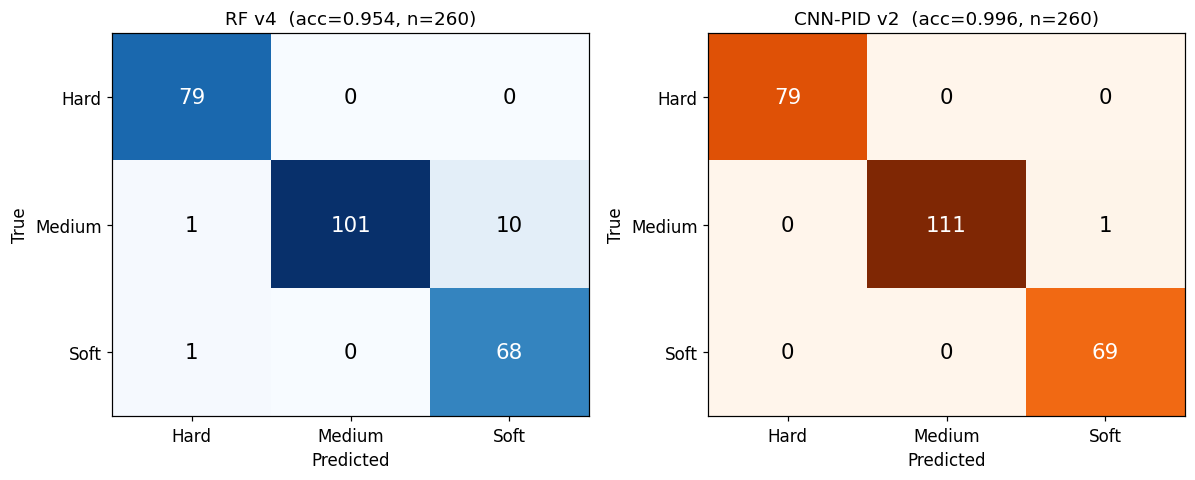

Saved C:\Users\charm\OneDrive\documents\Arduino\PIDpwm\Research\figures\fig3_confusion_matrices.png


In [5]:
# Fig 3 — Confusion matrices side-by-side
CLASSES = ['Hard','Medium','Soft']
def plot_cm(ax, y_t, y_p, title, cmap='Blues'):
    cm = confusion_matrix(y_t, y_p, labels=CLASSES)
    im = ax.imshow(cm, cmap=cmap, aspect='auto')
    ax.set_xticks(range(3)); ax.set_xticklabels(CLASSES)
    ax.set_yticks(range(3)); ax.set_yticklabels(CLASSES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    vm = max(cm.max(), 1)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    color='white' if cm[i,j] > vm*0.5 else 'black', fontsize=14)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_cm(axes[0], y_true, rf_pred,  f'RF v4  (acc={(y_true==rf_pred).mean():.3f}, n={len(y_true)})')
plot_cm(axes[1], y_true, cnn_pred, f'CNN-PID v2  (acc={(y_true==cnn_pred).mean():.3f}, n={len(y_true)})', cmap='Oranges')
out = os.path.join(FIG_DIR, 'fig3_confusion_matrices.png')
plt.tight_layout(); plt.savefig(out); plt.show()
print('Saved', out)

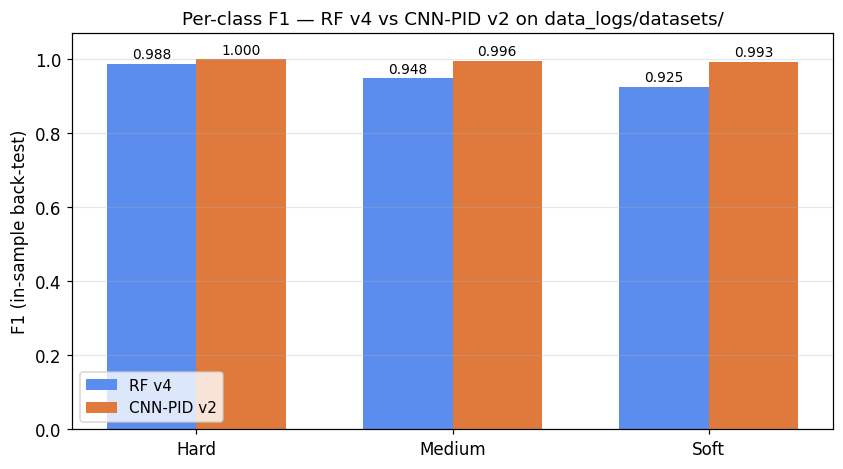

Saved C:\Users\charm\OneDrive\documents\Arduino\PIDpwm\Research\figures\fig4_per_class_f1.png


In [6]:
# Fig 4 — Per-class F1 bar chart
rf_f1  = f1_score(y_true, rf_pred,  labels=CLASSES, average=None, zero_division=0)
cnn_f1 = f1_score(y_true, cnn_pred, labels=CLASSES, average=None, zero_division=0)
x = np.arange(3); w = 0.35
fig, ax = plt.subplots(figsize=(7.8, 4.4))
b1 = ax.bar(x-w/2, rf_f1,  w, label='RF v4',      color='#5b8def')
b2 = ax.bar(x+w/2, cnn_f1, w, label='CNN-PID v2', color='#e07a3c')
ax.set_xticks(x); ax.set_xticklabels(CLASSES)
ax.set_ylabel('F1 (in-sample back-test)'); ax.set_ylim(0, 1.07)
ax.set_title('Per-class F1 — RF v4 vs CNN-PID v2 on data_logs/datasets/')
for b in (b1, b2):
    for r in b:
        ax.text(r.get_x()+r.get_width()/2, r.get_height()+0.015,
                f'{r.get_height():.3f}', ha='center', fontsize=9)
ax.legend(); ax.grid(axis='y', alpha=0.3)
out = os.path.join(FIG_DIR, 'fig4_per_class_f1.png')
plt.tight_layout(); plt.savefig(out); plt.show()
print('Saved', out)

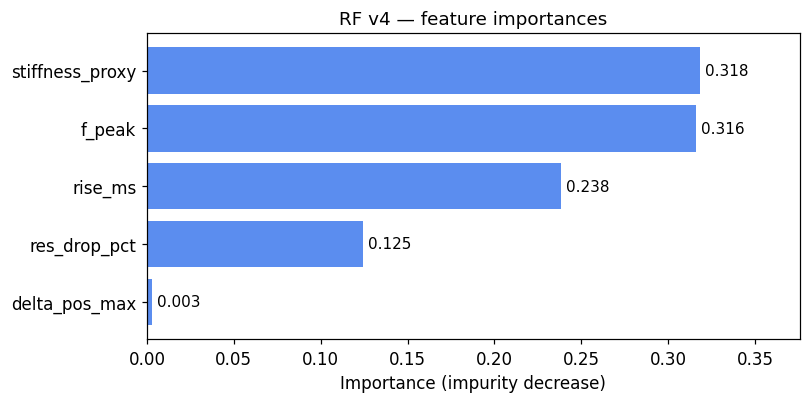

Saved C:\Users\charm\OneDrive\documents\Arduino\PIDpwm\Research\figures\fig5_rf_feature_importance.png


In [7]:
# Fig 5 — RF feature importance
imp = rf_model.feature_importances_
order = np.argsort(imp)
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.barh(np.array(RF_FEATURES)[order], imp[order], color='#5b8def')
for i, v in enumerate(imp[order]):
    ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=10)
ax.set_xlabel('Importance (impurity decrease)')
ax.set_title('RF v4 — feature importances')
ax.set_xlim(0, max(imp) * 1.18)
out = os.path.join(FIG_DIR, 'fig5_rf_feature_importance.png')
plt.tight_layout(); plt.savefig(out); plt.show()
print('Saved', out)

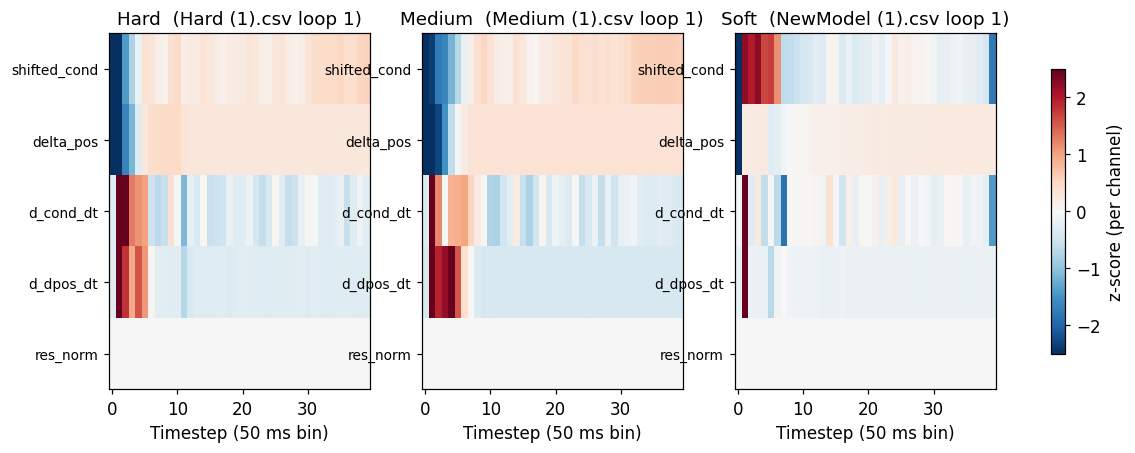

Saved C:\Users\charm\OneDrive\documents\Arduino\PIDpwm\Research\figures\fig6_example_windows.png


In [8]:
# Fig 6 — Example (40,5) window heatmaps for one Hard, one Medium, one Soft trial
examples = {}
for i, r in enumerate(rows):
    if r['label'] not in examples:
        examples[r['label']] = i
    if len(examples) == 3:
        break

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, (lbl, i) in zip(axes, examples.items()):
    W = X_cnn[i]
    # per-channel z-score so the heatmap is comparable across rows
    Wz = (W - W.mean(axis=0)) / (W.std(axis=0) + 1e-6)
    im = ax.imshow(Wz.T, aspect='auto', cmap='RdBu_r', vmin=-2.5, vmax=2.5)
    ax.set_yticks(range(5)); ax.set_yticklabels(CNN_FEATURES, fontsize=9)
    ax.set_xlabel('Timestep (50 ms bin)')
    ax.set_title(f'{lbl}  ({rows[i]["source"]} loop {rows[i]["loop"]})')
fig.colorbar(im, ax=axes, label='z-score (per channel)', shrink=0.8)
out = os.path.join(FIG_DIR, 'fig6_example_windows.png')
plt.savefig(out); plt.show()
print('Saved', out)

In [9]:
for f in sorted(os.listdir(FIG_DIR)):
    p = os.path.join(FIG_DIR, f)
    print(f'{f:40s}  {os.path.getsize(p)//1024} KB')

fig1_example_signal.png                   85 KB
fig2_class_mean_trajectories.png          98 KB
fig3_confusion_matrices.png               41 KB
fig4_per_class_f1.png                     41 KB
fig5_rf_feature_importance.png            36 KB
fig6_example_windows.png                  57 KB
